STEP 2: Loading and merging datasets
Seccessfully merged data. Combined dataset
   OrderID CustomerID ProductID  Quantity    SaleDate         Product_Name  \
0  TRN-401       C101   PROD-12       2.0  2026-04-01       Aso-Oke Agbada   
1  TRN-402       C102   PROD-14       1.0  2026-04-02  Ankara Summer Dress   
2  TRN-403       C103   PROD-12       NaN  2026-04-02       Aso-Oke Agbada   

      Category Price_Naira  
0  Traditional    ₦150,000  
1       Casual     ₦35,000  
2  Traditional    ₦150,000  
----------------------------------------

--- STEP 2: ADVANCED DATA CLEANING ---
-> Imputed missing values in 'Quantity' with column median: 1.5
-> Cleaned 'Price_Naira' and converted to numerical float.
-> Parsed 'SaleDate' columns to standard datetime formats.
----------------------------------------

--- STEP 3: FEATURE ENGINEERING ---
-> Engineered 'Total_Revenue' column successfully.
          Product_Name  Quantity  Price_Naira  Total_Revenue
0       Aso-Oke Agbada       2.0     1

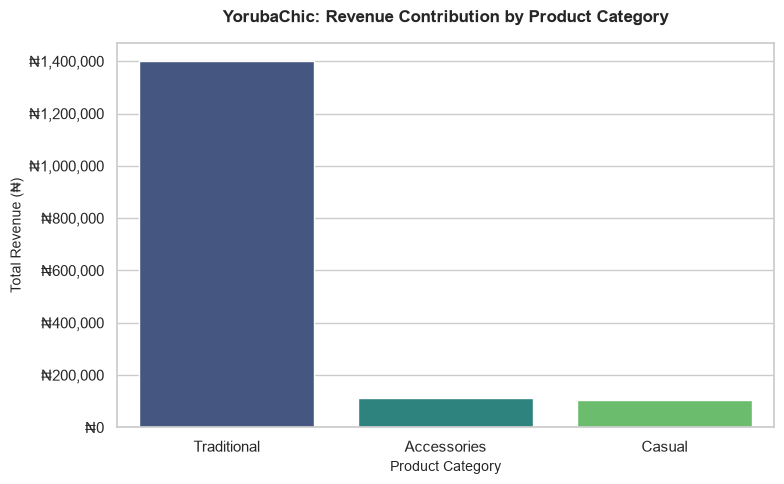

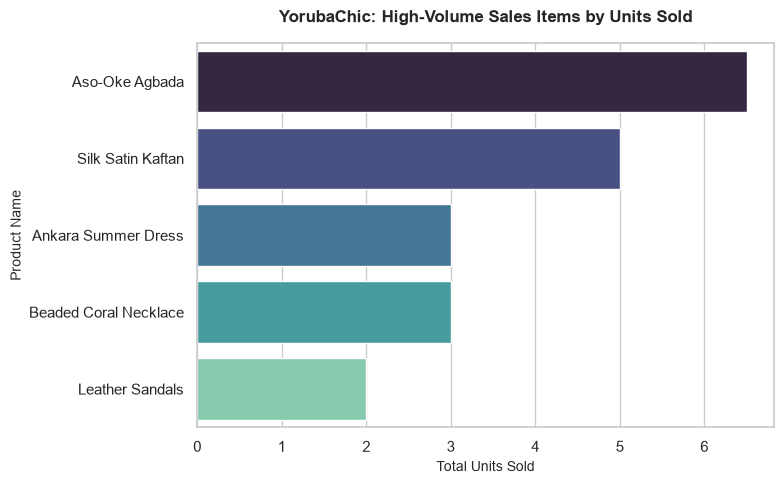

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

#set professional ploting aestetics
sns.set_theme(style="whitegrid")

print("STEP 2: Loading and merging datasets")
sales_df=pd.read_csv("sales_records.csv")
products_df = pd.read_csv("product_metadata.csv")

#Merge the dataset using INNER JOIN on productID
df = pd.merge(sales_df, products_df, on="ProductID", how="inner")
print("Seccessfully merged data. Combined dataset")
print(df.head(3))
print("-" * 40)

print("\n--- STEP 2: ADVANCED DATA CLEANING ---")

# 1. Handle missing values in 'Quantity' by filling with the median
quantity_median = df['Quantity'].median()
#df['Quantity'].fillna(quantity_median, inplace=True)
df['Quantity'] = df['Quantity'].fillna(quantity_median)
print(f"-> Imputed missing values in 'Quantity' with column median: {quantity_median}")

# 2. Clean 'Price_Naira' column: remove '₦' and commas, then convert to float
# Force the column to text (string) format BEFORE applying .str.replace
df['Price_Naira'] = df['Price_Naira'].astype(str).str.replace('₦', '').str.replace(',', '').astype(float)
print("-> Cleaned 'Price_Naira' and converted to numerical float.")

# 3. Parse 'SaleDate' into proper datetime objects
df['SaleDate'] = pd.to_datetime(df['SaleDate'])
print("-> Parsed 'SaleDate' columns to standard datetime formats.")
print("-" * 40)

print("\n--- STEP 3: FEATURE ENGINEERING ---")
# Create the Total_Revenue column
df['Total_Revenue'] = df['Price_Naira'] * df['Quantity']
print("-> Engineered 'Total_Revenue' column successfully.")
print(df[['Product_Name', 'Quantity', 'Price_Naira', 'Total_Revenue']].head(3))
print("-" * 40)

print("\n--- STEP 4: OUTLIER DETECTION (IQR METHOD) ---")
# Calculate IQR for Total_Revenue
Q1 = df['Total_Revenue'].quantile(0.25)
Q3 = df['Total_Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter for outliers
outliers = df[(df['Total_Revenue'] < lower_bound) | (df['Total_Revenue'] > upper_bound)]

print(f"Lower Outlier Boundary: ₦{lower_bound:,.2f}")
print(f"Upper Outlier Boundary: ₦{upper_bound:,.2f}")
print(f"Number of statistical outlier transactions found: {len(outliers)}")
if len(outliers) > 0:
    print("\nOutlier Transactions:")
    print(outliers[['OrderID', 'Product_Name', 'Total_Revenue']])
print("-" * 40)

print("\n--- STEP 5: VISUALIZATIONS ---")

# Chart 1: Total Revenue Generated by Category

# --- CHART 1: RUN THIS ALL IN ONE CELL ---
plt.figure(figsize=(8, 5))

# Process data
category_rev = df.groupby('Category')['Total_Revenue'].sum().reset_index()
category_rev = category_rev.sort_values(by='Total_Revenue', ascending=False)

# Draw the plot explicitly pointing to the dataframe and columns
sns.barplot(
    x='Category', 
    y='Total_Revenue', 
    data=category_rev, 
    palette='viridis',
    hue='Category', # Added to comply with modern seaborn styling
    legend=False
)

# Customize axes and titles
plt.title("YorubaChic: Revenue Contribution by Product Category", fontsize=12, weight='bold', pad=15)
plt.xlabel("Product Category", fontsize=10)
plt.ylabel("Total Revenue (₦)", fontsize=10)

# Use the professional formatter we discussed to add the ₦ currency symbol safely
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'₦{x:,.0f}'))

# Save and display while the figure context is still alive
plt.tight_layout()
plt.savefig('category_revenue.png', dpi=300) # dpi=300 makes it high resolution
plt.show()

# Chart 2: Total Unit Volumes Sold by Product Name
# --- CHART 2: RUN THIS ALL IN ONE CELL ---
plt.figure(figsize=(8, 5))

# Process data
product_vol = df.groupby('Product_Name')['Quantity'].sum().reset_index()
product_vol = product_vol.sort_values(by='Quantity', ascending=False)

# Draw the horizontal plot
sns.barplot(
    x='Quantity', 
    y='Product_Name', 
    data=product_vol, 
    palette='mako', 
    orient='h',
    hue='Product_Name',
    legend=False
)

# Customize axes and titles
plt.title("YorubaChic: High-Volume Sales Items by Units Sold", fontsize=12, weight='bold', pad=15)
plt.xlabel("Total Units Sold", fontsize=10)
plt.ylabel("Product Name", fontsize=10)

# Save and display
plt.tight_layout()
plt.savefig('product_volume.png', dpi=300)
plt.show()